## 3.4 Terminal ingredients

**(a)**

$A = \begin{bmatrix} 0.9 & 0.6 \\ 0 & 0.8 \end{bmatrix}$ has eigenvalues $0.9$ and $0.8$, both strictly less than $1$, so the uncontrolled system $x_{t+1} = Ax_t$ is asymptotically stable. This allows us to design $\mathcal{X}_T$ and $P$ using only $x_{t+1} = Ax_t$ with $u = 0$.

Recursive feasibility requires $\mathcal{X}_T$ to be a positive invariant set for $x_{t+1} = Ax_t$ contained in $\mathcal{X} = \{x : \|x\|_2 \le r_x\}$. We could take $\mathcal{X}_T = \mathcal{O}_\infty$, the maximal positive invariant set within $\mathcal{X}$.

To use the MPC stability theorem (for quadratic cost), we verify:

A0: $Q = Q^\top \succ 0$, $R = R^\top \succ 0$, $P \succ 0$. This holds since $Q = I$, $R = I$, and we choose $P \succ 0$.

A1: $\mathcal{X}$, $\mathcal{X}_T$, and $\mathcal{U}$ contain the origin in their interior and are closed. This holds by construction.

A2: $\mathcal{X}_T \subseteq \mathcal{X}$ is control invariant and bounded. Since $u = 0$ is a feasible control and $\mathcal{X}_T$ is positive invariant under $x_{t+1} = Ax_t$, it is control invariant for the full system.

A3: Since $u = 0$ is feasible and $Ax \in \mathcal{X}_T$ if $x \in \mathcal{X}_T$, assumption A3 becomes

$$-x^\top P x + x^\top Q x + x^\top A^\top P A\, x \le 0, \quad \forall x \in \mathcal{X}_T,$$

which is true since, due to the fact that $A$ is asymptotically stable,

$$\exists\, P \succ 0 \;\text{ s.t. }\; -P + Q + A^\top P A = 0 \quad \text{(discrete Lyapunov equation).}$$

**(b)**

Let $x \in \mathcal{X}_T$, i.e., $x^\top W x \le 1$.

Positive invariance: since $A^\top W A - W \preceq 0$,

$$(Ax)^\top W (Ax) = x^\top A^\top W A\, x \le x^\top W x \le 1,$$

so $Ax \in \mathcal{X}_T$. Hence $\mathcal{X}_T$ is positive invariant for $x_{t+1} = Ax_t$.

State constraints: since $I - r_x^2 W \preceq 0$,

$$x^\top (I - r_x^2 W) x \le 0$$
$$\Rightarrow \|x\|_2^2 \le r_x^2\, x^\top W x$$

Since $x \in \mathcal{X}_T$, $x^\top W x \le 1$, so

$$\|x\|_2^2 \le r_x^2 \cdot 1 = r_x^2$$
$$\Rightarrow \|x\|_2 \le r_x$$
$$\Rightarrow \mathcal{X}_T \subseteq \mathcal{X} \quad \text{(respects state constraints).}$$

**(c)**

Let $M := W^{-1}$. Since $W$ is symmetric positive definite, its eigenvalues $\lambda_i > 0$. The eigenvalues of $M = W^{-1}$ are $1/\lambda_i > 0$, and $M$ is symmetric (the inverse of a symmetric matrix is symmetric), so $M$ is also symmetric positive definite. Reciprocally, $M \succ 0 \Rightarrow W = M^{-1} \succ 0$ by the same argument.

Constraint 1: $A^\top W A - W \preceq 0$ with $W = M^{-1}$:

$$A^\top M^{-1} A \preceq M^{-1} \iff M^{-1} - A^\top M^{-1} A \succeq 0$$

Using hint 1 (pre/post multiply by $M \succ 0$):

$$M(M^{-1} - A^\top M^{-1} A)M = M - (AM)^\top M^{-1}(AM) \succeq 0$$

By Schur's complement lemma:

$$\begin{bmatrix} M & MA^\top \\ AM & M \end{bmatrix} \succeq 0$$

Constraint 2: $I - r_x^2 W \preceq 0$ with $W = M^{-1}$:

$$r_x^2 M^{-1} \succeq I \iff M^{-1} \succeq \frac{1}{r_x^2} I$$

By hint 2 ($A^{-1} \succeq \frac{1}{\gamma}I \iff A \preceq \gamma I$):

$$M \preceq r_x^2 I \iff r_x^2 I - M \succeq 0$$

Objective: $\log\det(W^{-1}) = \log\det(M)$, which is concave in $M \succ 0$.

The reformulated concave SDP is:

$$\underset{M \succ 0}{\text{maximize}} \quad \log\det(M)$$
$$\text{subject to} \quad \begin{bmatrix} M & MA^\top \\ AM & M \end{bmatrix} \succeq 0$$
$$r_x^2 I - M \succeq 0$$

**(d)**

W = M^{-1} =
[[0.041 0.013]
 [0.013 0.198]]


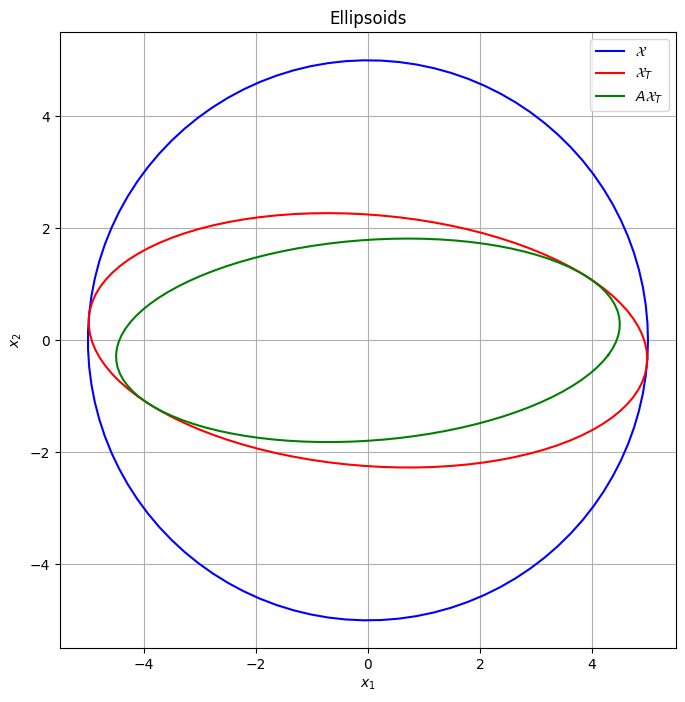

In [1]:
import numpy as np
import cvxpy as cvx
import matplotlib.pyplot as plt

A = np.array([[0.9, 0.6], [0.0, 0.8]])
B = np.array([[0.0], [1.0]])
n = 2
rx = 5.0
ru = 1.0
Q = np.eye(n)
R = np.eye(1)
P = np.eye(n)
N = 4

# Solve the SDP for M
M = cvx.Variable((n, n), symmetric=True)
constraints = [
    cvx.bmat([[M, M @ A.T], [A @ M, M]]) >> 0,
    rx**2 * np.eye(n) - M >> 0,
]
prob = cvx.Problem(cvx.Maximize(cvx.log_det(M)), constraints)
prob.solve(cvx.SCS)

M_val = M.value
W_val = np.linalg.inv(M_val)
print(f"W = M^{{-1}} =\n{np.round(W_val, 3)}")

def generate_ellipsoid_points(M, num_points=100):
    L = np.linalg.cholesky(M)
    theta = np.linspace(0, 2 * np.pi, num_points)
    u = np.column_stack([np.cos(theta), np.sin(theta)])
    x = u @ L.T
    return x

X_pts = generate_ellipsoid_points(rx**2 * np.eye(n))
XT_pts = generate_ellipsoid_points(M_val)
AXT_pts = (A @ XT_pts.T).T

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(X_pts[:, 0], X_pts[:, 1], 'b-', label=r'$\mathcal{X}$')
ax.plot(XT_pts[:, 0], XT_pts[:, 1], 'r-', label=r'$\mathcal{X}_T$')
ax.plot(AXT_pts[:, 0], AXT_pts[:, 1], 'g-', label=r'$A\mathcal{X}_T$')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title('Ellipsoids')
ax.set_aspect('equal')
ax.legend()
ax.grid(True)
plt.show()

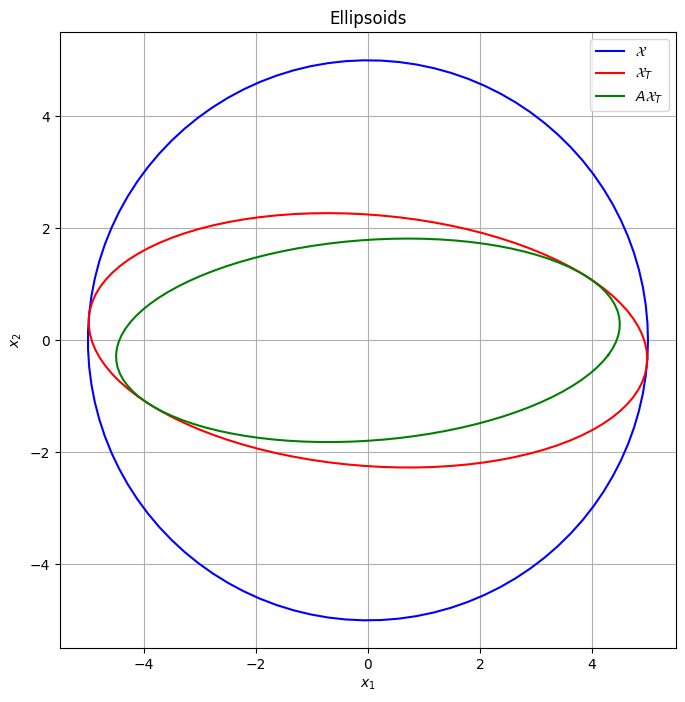

In [2]:
from IPython.display import Image, display
display(Image(filename='ellipsoids.png', width=600))

**(e)**

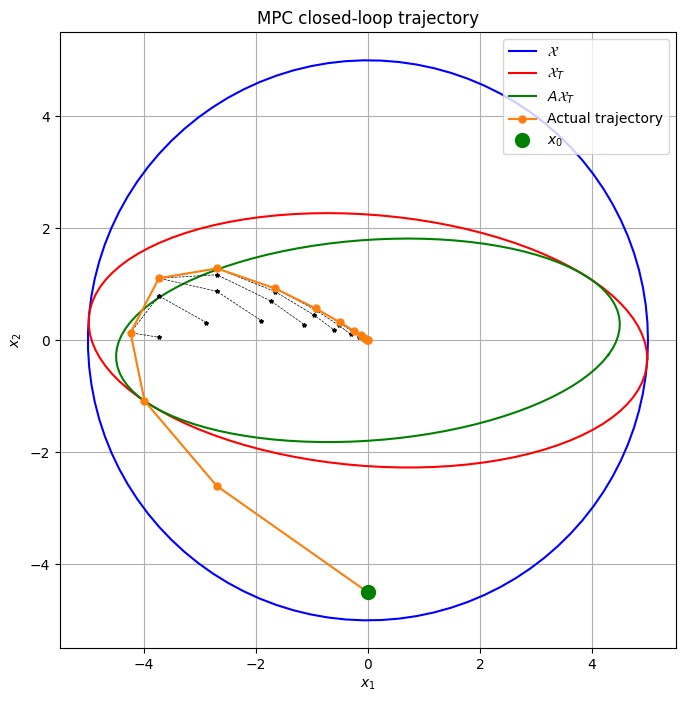

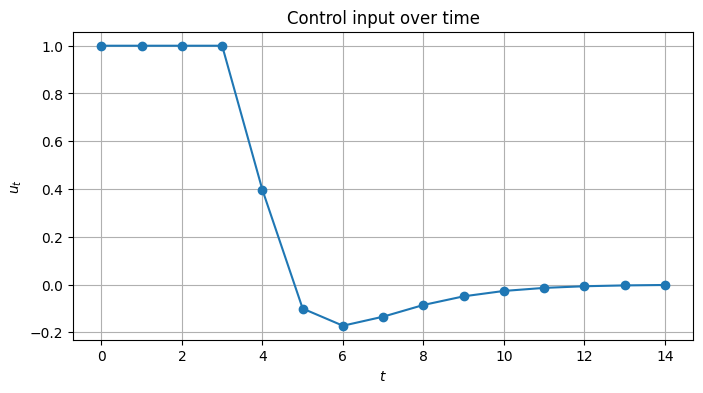

In [3]:
# Parameterized MPC problem
x0_param = cvx.Parameter(n)
x_mpc = cvx.Variable((N + 1, n))
u_mpc = cvx.Variable((N, 1))

cost = cvx.quad_form(x_mpc[N], P)
for k in range(N):
    cost += cvx.quad_form(x_mpc[k], Q) + cvx.quad_form(u_mpc[k], R)

mpc_constraints = [x_mpc[0] == x0_param]
for k in range(N):
    mpc_constraints += [
        x_mpc[k + 1] == A @ x_mpc[k] + B @ u_mpc[k],
        cvx.norm2(x_mpc[k]) <= rx,
        cvx.norm2(u_mpc[k]) <= ru,
    ]
mpc_constraints += [cvx.quad_form(x_mpc[N], W_val) <= 1]

mpc_prob = cvx.Problem(cvx.Minimize(cost), mpc_constraints)

# Simulate from x0 = (0, -4.5) for 15 steps
T_sim = 15
x0 = np.array([0.0, -4.5])
x_actual = np.zeros((T_sim + 1, n))
u_actual = np.zeros((T_sim, 1))
x_planned = []

x_actual[0] = x0
for t in range(T_sim):
    x0_param.value = x_actual[t]
    mpc_prob.solve(cvx.CLARABEL)
    x_planned.append(x_mpc.value.copy())
    u_actual[t] = u_mpc.value[0, :]
    x_actual[t + 1] = A @ x_actual[t] + B.flatten() * u_actual[t, 0]

# State trajectories overlaid on ellipsoids
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(X_pts[:, 0], X_pts[:, 1], 'b-', label=r'$\mathcal{X}$')
ax.plot(XT_pts[:, 0], XT_pts[:, 1], 'r-', label=r'$\mathcal{X}_T$')
ax.plot(AXT_pts[:, 0], AXT_pts[:, 1], 'g-', label=r'$A\mathcal{X}_T$')
for t in range(T_sim):
    ax.plot(x_planned[t][:, 0], x_planned[t][:, 1], '--*', color='k', markersize=3, linewidth=0.5)
ax.plot(x_actual[:, 0], x_actual[:, 1], '-o', color='tab:orange', markersize=5, label='Actual trajectory')
ax.plot(x_actual[0, 0], x_actual[0, 1], 'go', markersize=10, label=r'$x_0$')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title('MPC closed-loop trajectory')
ax.set_aspect('equal')
ax.legend()
ax.grid(True)
plt.show()

# Control input over time
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(T_sim), u_actual[:, 0], '-o')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$u_t$')
ax.set_title('Control input over time')
ax.grid(True)
plt.show()